# Exercise potential energy statically indeterminate structure

Find the displacement in C using potential energy and compare it to the result from solving the differential equation.

```{figure} data_exercise_pot_energy/structure.svg
---
name: structure
---

Structure
```

## Solve using potential energy

Let's start by defining the trial function. Let's assume a parabolic displacement field with the shape $u\left(x\right) = a + b x + c$.

```{exercise} Boundary conditions kinematical admissible trial function
:label: exercise_1
:nonumber: true

The displacement field must be kinematically admissible. Which boundary conditions must be enforced for that?
```

```{solution} exercise_1
:class: dropdown

- $u\left(0\right) = 0$
- $u\left(L\right) = 0$
```

```{exercise-start} Kinematical admissibility trial function
:label: exercise_2
:nonumber: true

Now, let's use SymPy to rewrite the trial function so that it is kinematically admissible.
```

In [ ]:
import sympy as sym
a, b, c, x, L, EA, F = sym.symbols('a, b, c, x, L, EA, F')

In [ ]:
u_trial_general = a + b * x + c * x **2

eq1 = sym.Eq(u_trial_general.subs(x, #value to substitute for x), #right hand side of equation)
eq2 = #...
sol = sym.solve((eq1,eq2),(a,b))
display(sol)
u_trial = u_trial_general.subs(sol)
display(u_trial)

Let's check your solution graphically for a value of $1$ for $c$ and $5$ for $L$:

In [55]:
import matplotlib.pyplot as plt
import numpy as np
%config InlineBackend.figure_formats = ['svg']

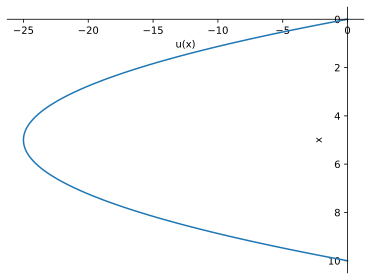

In [62]:
u_trial_func = sym.lambdify(x, u_trial.subs(sol).subs(c,1).subs(L,5))
x_plot = np.linspace(0, 10,100)
fig, ax = plt.subplots()
ax.plot(u_trial_func(x_plot),x_plot)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('u(x)')
ax.set_ylabel('x')
ax.invert_yaxis()
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


```{exercise-end}
```

```{solution-start} exercise_2
:class: dropdown
```

The answer should be $-2 \ L \ c \ x + c \ x^2$
And the graph should match your boundary conditions of [exercise on boundary conditions kinematical admissible trial function](exercise_1)

In [22]:
import sympy as sym
a, b, c, x, L, EA, F = sym.symbols('a, b, c, x, L, EA, F')

In [ ]:
u_trial_general = a+b*x+c*x**2

eq1 = sym.Eq(u_trial_general.subs(x,0), 0)
eq2 = sym.Eq(u_trial_general.subs(x,2*L), 0)
sol = sym.solve((eq1,eq2),(a,b))
display(sol)
u_trial = u_trial_general.subs(sol)
display(u_trial)

{a: 0, b: -2*L*c}

-2*L*c*x + c*x**2

```{solution-end}
```

For the strain energy we needed the strain distribution instead of the displacement. The strain is the derivative of the displacement, which can be found with SymPy:

In [65]:
epsilon_trial = sym.diff(u_trial,x)
display(epsilon_trial)

-2*L*c + 2*c*x

```{exercise-start} strain energy
:label: exercise_3
:nonumber: true

Now let's evaluate the strain energy:
```

In [ ]:
E_v_trial = sym.integrate(#term to integrate,(x,#integrate from, #integrate to)) + ...
display(E_v_trial)

```{exercise-end}
```

```{solution-start} exercise_3
:class: dropdown
```

The answer should be $2 \ EA \ L^3 c^2$

In [68]:
E_v_trial = sym.integrate(EA*epsilon_trial**2/2,(x,0,L))+sym.integrate(EA*2*epsilon_trial**2/2,(x,L,2*L))
display(E_v_trial)

2*EA*L**3*c**2

```{solution-end}
```

```{exercise} Work by force
:label: exercise_4
:nonumber: true

What's the work done by the force $F$?
```

```{solution} exercise_4
:class: dropdown

$$- F \cdot u(L)$$

```

```{exercise-start} Potential energy
:label: exercise_5
:nonumber: true

Find the relation for the potential energy.
```

In [ ]:
V = #expression for V
display(V)

```{exercise-end}
```

```{solution-start} exercise_5
:class: dropdown
```

The answer should be $2 EA \ L^3 c^2 - F\ L^2 c$

In [69]:
V = E_v_trial - ( -F * u_trial.subs(x,L))
display(V)

2*EA*L**3*c**2 - F*L**2*c

```{solution-end}
```

```{exercise-start} Stationary strain energy
:label: exercise_6
:nonumber: true

Now, let's impose the stationary condition for the strain energy in an equation which we can use to solve for the unknown $c$.
```

In [ ]:
eq3 = sym.Eq(#left hand side of equation, #right hand side of equation)
display(eq3)
c_sol = sym.solve(eq3,c)[0]
display(c_sol)
u_trial_sol = u_trial.subs(c,c_sol)
display(u_trial_sol)

Let's check your solution graphically for a value of $5$ m for $L$, $2000$ kN for $EA$ and $30$ kN for $F$:

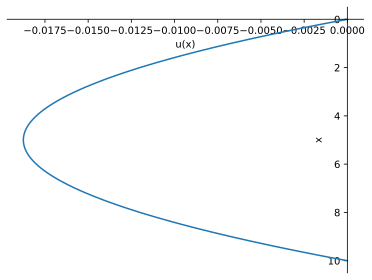

In [74]:
u_trial_func = sym.lambdify(x, u_trial_sol.subs(sol).subs(L,5).subs(EA,2000).subs(F,30))
x_plot = np.linspace(0, 10,100)
fig, ax = plt.subplots()
ax.plot(u_trial_func(x_plot),x_plot)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('u(x)')
ax.set_ylabel('x')
ax.invert_yaxis()
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


```{exercise-end}
```

```{solution-start} exercise_6
:class: dropdown
```

The answer should be $\cfrac{F \ x}{2 \ EA} + \cfrac{ F \ x^2}{4 \ EA \ L}$

In [75]:
eq3 = sym.Eq(V.diff(c),0)
display(eq3)
c_sol = sym.solve(eq3,c)[0]
display(c_sol)
u_trial_sol = u_trial.subs(c,c_sol)
display(u_trial_sol)

Eq(4*EA*L**3*c - F*L**2, 0)

F/(4*EA*L)

-F*x/(2*EA) + F*x**2/(4*EA*L)

```{solution-end}
```

## Solve with differential equation

Now, let's solve the same structure using the differential equation.

```{exercise-start} Generalised relations
:label: exercise_7
:nonumber: true

```
Given a load $q=0$, integrate twice to find the normal force, strain and displacement relations with integration constants:

In [ ]:
C_1, C_2, C_3, C_4 = sym.symbols('C_1, C_2, C_3, C_4')

q_AC = 0
q_BC = 0

N_AC = C_1 + sym.integrate(#..., x)
N_BC = C_3 + #...

display(N_AC)
display(N_BC)

epsilon_AC = #...
epsilon_BC = #...

display(epsilon_AC)
display(epsilon_BC)

u_AC = C_2 + #...
u_BC = C_3 + #...

display(u_AC)
display(u_BC)

```{exercise-end}
```

```{solution-start} exercise_7
:class: dropdown
```

You should have found:

- $N_{\text{AC}} = C_1$
- $N_{\text{BC}} = C_3$
- $\epsilon_{\text{AC}} = \cfrac{C_1}{EA}$
- $\epsilon_{\text{BC}} = \cfrac{C_3}{BA}$
- $u_{\text{AC}} = \cfrac{C_1}{EA} x + C_2$
- $u_{\text{BC}} = \cfrac{C_3}{EA} x + C_4$

In [84]:
C_1, C_2, C_3, C_4 = sym.symbols('C_1, C_2, C_3, C_4')

q_AC = 0
q_BC = 0

N_AC = C_1 + sym.integrate(q_AC, x)
N_BC = C_3 + sym.integrate(q_BC, x)

display(N_AC)
display(N_BC)

epsilon_AC = N_AC / EA
epsilon_BC = N_BC / EA

display(epsilon_AC)
display(epsilon_BC)

u_AC = C_2 + sym.integrate(epsilon_AC, x)
u_BC = C_4 + sym.integrate(epsilon_BC, x)

display(u_AC)
display(u_BC)

C_1

C_3

C_1/EA

C_3/EA

C_1*x/EA + C_2

C_3*x/EA + C_4

```{solution-end}
```

```{exercise} Boundary conditions
:label: exercise_8
:nonumber: true

What are the boundary conditions?
```

```{solution} exercise_8
:class: dropdown

- $u_\text{AC} \left(0\right)=0$
- $u_\text{AC} \left(L\right)=u_\text{BC} \left(L\right)$
- $u_\text{BC} \left(2 \ L \right) = 0$
- $N_\text{AC} \left(L\right) + F = N_\text{BC} \left( L\right)$
```

```{exercise-start} Solve boundary conditions
:label: exercise_9
:nonumber: true

Now, let's use SymPy to solve for the boundary conditions using `sym.solve` similarly as you did in [the exercise for the kinematical admissibility trial function](exercise_2) and find the solution for $u_\text{AC}$ and $u_\text{BC}
```

In [ ]:
eq4 = #...
#...

C_sol = sym.solve((eq4,#...),[#])
display(sol)

u_AC_sol = u_AC.subs(C_sol)
u_BC_sol = u_BC.subs(C_sol)
display(u_AC_sol)
display(u_BC_sol)

Let's check your solution graphically for a value of $5$ m for $L$, $2000$ kN for $EA$ and $30$ kN for $F$:

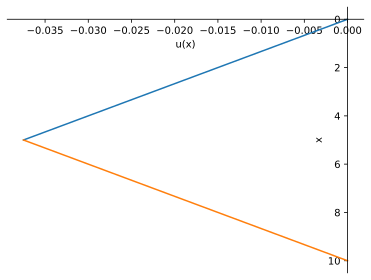

In [ ]:
u_AC_func = sym.lambdify(x, u_AC_sol.subs(sol).subs(L,5).subs(EA,2000).subs(F,30))
u_BC_func = sym.lambdify(x, u_BC_sol.subs(sol).subs(L,5).subs(EA,2000).subs(F,30))
x_plot_AC = np.linspace(0, 5,100)
x_plot_BC = np.linspace(5, 10,100)
fig, ax = plt.subplots()
ax.plot(u_AC_func(x_plot_AC),x_plot_AC)
ax.plot(u_BC_func(x_plot_BC),x_plot_BC)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('u(x)')
ax.set_ylabel('x')
ax.invert_yaxis()
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


```{exercise-end}
```

```{solution-start} exercise_7
:class: dropdown
```

You should find:
- $u_\text{AC} = -\cfrac{F \ x}{2 \ EA}$
- $u_\text{BC} = -\cfrac{F \ L}{EA} + \cfrac{F \ x}{2 \ EA}$

```{exercise-end}
```

```{solution-start} exercise_7
:class: dropdown
```

You should find:
- $u_\text{AC} = -\cfrac{F \ x}{2 \ EA}$
- $u_\text{BC} = -\cfrac{F \ L}{EA} + \cfrac{F \ x}{2 \ EA}$

In [85]:
eq4 = sym.Eq(u_AC.subs(x,0), 0)
eq5 = sym.Eq(u_AC.subs(x,L), u_BC.subs(x,L))
eq6 = sym.Eq(u_BC.subs(x,2*L), 0)
eq7 = sym.Eq(N_AC.subs(x,L)+F, N_BC.subs(x,L))

display(eq4)
display(eq5)
display(eq6)
display(eq7)

C_sol = sym.solve((eq4,eq5,eq6,eq7),(C_1,C_2,C_3,C_4))
display(C_sol)

u_AC_sol = u_AC.subs(C_sol)
u_BC_sol = u_BC.subs(C_sol)
display(u_AC_sol)
display(u_BC_sol)

Eq(C_2, 0)

Eq(C_1*L/EA + C_2, C_3*L/EA + C_4)

Eq(2*C_3*L/EA + C_4, 0)

Eq(C_1 + F, C_3)

{C_1: -F/2, C_2: 0, C_3: F/2, C_4: -F*L/EA}

-F*x/(2*EA)

-F*L/EA + F*x/(2*EA)

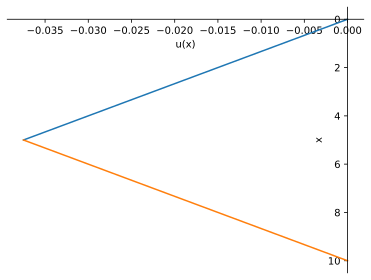

In [ ]:
u_AC_func = sym.lambdify(x, u_AC_sol.subs(sol).subs(L,5).subs(EA,2000).subs(F,30))
u_BC_func = sym.lambdify(x, u_BC_sol.subs(sol).subs(L,5).subs(EA,2000).subs(F,30))
x_plot_AC = np.linspace(0, 5,100)
x_plot_BC = np.linspace(5, 10,100)
fig, ax = plt.subplots()
ax.plot(u_AC_func(x_plot_AC),x_plot_AC)
ax.plot(u_BC_func(x_plot_BC),x_plot_BC)
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.set_xlabel('u(x)')
ax.set_ylabel('x')
ax.invert_yaxis()
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)


```{solution-end}
```